<a href="https://colab.research.google.com/github/idkwhatimdoing67/FundML/blob/Version-1/FundML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
import io

# 1. Trigger the upload dialog to select the .gz file from your PC
uploaded = files.upload()

# 2. Get the filename from the upload dictionary
filename = list(uploaded.keys())[0]

# 3. Read the compressed file into a DataFrame
# Pandas automatically handles 'gzip' compression by default
df = pd.read_csv(io.BytesIO(uploaded[filename]), compression='gzip')

# 4. Preview the data
print(f"Successfully loaded: {filename}")
display(df.head())

Saving ETF_ML_Monthly_Dataset.gz to ETF_ML_Monthly_Dataset.gz
Successfully loaded: ETF_ML_Monthly_Dataset.gz


,ref.date,ticker,price.close,ret.closing.prices,BAMLH0A0HYM2,UNRATE,FF_Mkt-RF,FF_SMB,FF_HML,FF_RMW,FF_CMA,FF_RF,FF_Mom,FF_ST_Rev,inflation,m2_growth,fed_funds_chg,yield_curve_delta,vix_log_ret,target_next_month_ret
0,2004-10-22,XLK,9.710,-0.021662,3.78,5.5,0.0142,0.0015,-0.0026,-0.0053,0.0041,0.0011,-0.0143,0.0024,0.0,0.0,0.0,0.00,0.049641,0.083419
1,2004-10-25,XLK,9.695,-0.001545,3.76,5.5,0.0142,0.0015,-0.0026,-0.0053,0.0041,0.0011,-0.0143,0.0024,0.0,0.0,0.0,0.03,0.081652,0.080454
2,2004-10-26,XLK,9.715,0.002063,3.72,5.5,0.0142,0.0015,-0.0026,-0.0053,0.0041,0.0011,-0.0143,0.0024,0.0,0.0,0.0,0.05,-0.011526,0.086979
3,2004-10-27,XLK,9.950,0.024189,3.61,5.5,0.0142,0.0015,-0.0026,-0.0053,0.0041,0.0011,-0.0143,0.0024,0.0,0.0,0.0,0.01,-0.041738,0.059799
4,2004-10-28,XLK,9.975,0.002513,3.58,5.5,0.0142,0.0015,-0.0026,-0.0053,0.0041,0.0011,-0.0143,0.0024,0.0,0.0,0.0,0.01,-0.021216,0.057644


In [ ]:
# Optional: Ensure dates are handled correctly for time-series modeling
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Convert to datetime and find the max
df['ref.date'] = pd.to_datetime(df['ref.date'])
latest_date = df['ref.date'].max()

print(f"The most recent data point is: {latest_date}")

The most recent data point is: 2026-03-09 00:00:00


In [ ]:
# 1. Ensure ref.date is datetime (already done in your Colab, but good for safety)
df['ref.date'] = pd.to_datetime(df['ref.date'])

# 2. Sort by date and ticker to ensure the chronological order is preserved
df = df.sort_values(by=['ref.date', 'ticker'])

# 3. Downsample to monthly
# We use 'groupby' on ticker and 'resample' on date to get the last entry of each month
df_monthly = (
    df.set_index('ref.date')
    .groupby('ticker')
    .resample('ME')  # 'ME' stands for Month End
    .last()          # Takes the last available record for that month
    .drop(columns='ticker') # Drop ticker from columns since it's now in the index
    .reset_index()
)

# 4. Filter out any potential NaN targets that might have appeared if an ETF launched mid-month
df_monthly = df_monthly.dropna(subset=['target_next_month_ret'])

# 5. Check the result
print(f"Original shape: {df.shape}")
print(f"Monthly shape: {df_monthly.shape}")
display(df_monthly.head())

Original shape: (59143, 20)
Monthly shape: (2838, 20)


,ticker,ref.date,price.close,ret.closing.prices,BAMLH0A0HYM2,UNRATE,FF_Mkt-RF,FF_SMB,FF_HML,FF_RMW,FF_CMA,FF_RF,FF_Mom,FF_ST_Rev,inflation,m2_growth,fed_funds_chg,yield_curve_delta,vix_log_ret,target_next_month_ret
0,IYR,2004-10-31,56.755001,-0.002548,3.56,5.5,0.0142,0.0015,-0.0026,-0.0053,0.0041,0.0011,-0.0143,0.0024,0.000000,0.000000,0.00,-0.02,0.055605,0.042463
1,IYR,2004-11-30,59.165001,0.004499,3.17,5.4,0.0453,0.0412,0.0157,-0.0052,-0.0018,0.0015,0.0308,0.0149,0.004717,0.004154,0.17,-0.15,-0.004521,0.043945
2,IYR,2004-12-31,61.599998,-0.002671,3.10,5.4,0.0341,-0.0004,-0.0023,-0.0107,0.0039,0.0016,-0.0285,0.0097,0.000000,0.000000,0.00,-0.21,0.056495,-0.071510
3,IYR,2005-01-31,56.349998,-0.006348,3.29,5.4,-0.0275,-0.0111,0.0206,0.0280,-0.0141,0.0016,0.0296,0.0150,0.000000,0.000000,0.00,-0.32,-0.032236,0.038154
4,IYR,2005-02-28,58.230000,-0.006738,2.83,5.4,0.0188,-0.0030,0.0141,0.0132,-0.0021,0.0016,0.0343,-0.0247,0.003652,0.002241,0.34,-0.17,0.050074,-0.032973


In [ ]:
import pandas as pd

# 1. Map your proxies to the official S&P 500 SPDR Tickers
# Adjust the keys ('IYR', 'VOX') if you used different proxy tickers in your dataset
ticker_map = {
    'IYR': 'XLRE', # Standardizing Real Estate to XLRE
    'VOX': 'XLC'   # Standardizing Comm Services to XLC
}

df_monthly['ticker'] = df_monthly['ticker'].replace(ticker_map)

# 2. Drop any overlapping months (keep the actual SPDR data if both existed)
df_monthly = df_monthly.drop_duplicates(subset=['ref.date', 'ticker'], keep='last')

# 3. Strictly filter to ONLY the 11 official S&P 500 sectors
official_tickers = [
    'XLK', 'XLF', 'XLC', 'XLY', 'XLV', 'XLI',
    'XLP', 'XLE', 'XLU', 'XLB', 'XLRE'
]
df_monthly = df_monthly[df_monthly['ticker'].isin(official_tickers)].copy()

# Cast back to category for LightGBM
df_monthly['ticker'] = df_monthly['ticker'].astype('category')

print(f"Cleaned Dataset Shape: {df_monthly.shape}")
print(f"Unique Sectors: {df_monthly['ticker'].nunique()} (Should be exactly 11)")

Cleaned Dataset Shape: (2838, 20)
Unique Sectors: 11 (Should be exactly 11)


In [ ]:
import pandas as pd
import numpy as np

print("--- Starting LEAK-PROOF Cross-Sectional Feature Engineering ---")
print(f"Starting shape: {df_monthly.shape}")

# 1. Sort values by ticker and date to ensure chronological integrity
df_monthly = df_monthly.sort_values(['ticker', 'ref.date']).reset_index(drop=True)

# 2. Calculate Raw Trailing Returns (Micro Features)
# We calculate these on the 'current' row first...
df_monthly['raw_1M_ret'] = df_monthly.groupby('ticker', observed=False)['price.close'].pct_change(1)
df_monthly['raw_3M_ret'] = df_monthly.groupby('ticker', observed=False)['price.close'].pct_change(3)
df_monthly['raw_6M_ret'] = df_monthly.groupby('ticker', observed=False)['price.close'].pct_change(6)
df_monthly['raw_3M_vol'] = df_monthly.groupby('ticker', observed=False)['ret.closing.prices'].rolling(3).std().reset_index(level=0, drop=True)

# 3. APPLY THE SHIFT (The Leak Killer)
# We shift the features forward by 1 month.
# This ensures that for the 'January' row, the features are actually DECEMBER'S returns.
feature_cols_to_shift = ['raw_1M_ret', 'raw_3M_ret', 'raw_6M_ret', 'raw_3M_vol']
for col in feature_cols_to_shift:
    df_monthly[col] = df_monthly.groupby('ticker', observed=False)[col].shift(1)

# 4. CROSS-SECTIONAL RANKING
# Now we rank the shifted (historical) data against other ETFs for that month
def rank_cross_section(df, col_name):
    return df.groupby('ref.date')[col_name].rank(pct=True)

df_monthly['rank_1M_ret'] = rank_cross_section(df_monthly, 'raw_1M_ret')
df_monthly['rank_3M_ret'] = rank_cross_section(df_monthly, 'raw_3M_ret')
df_monthly['rank_6M_ret'] = rank_cross_section(df_monthly, 'raw_6M_ret')
df_monthly['rank_3M_vol'] = rank_cross_section(df_monthly, 'raw_3M_vol')

# 5. Clean up the raw columns
cols_to_drop_engineering = ['raw_1M_ret', 'raw_3M_ret', 'raw_6M_ret', 'raw_3M_vol']
df_monthly = df_monthly.drop(columns=cols_to_drop_engineering)

# 6. Drop NaNs created by the 6-month lookback AND the 1-month shift
# We now drop the first 7 months of each ticker
df_monthly = df_monthly.dropna(subset=['rank_6M_ret', 'rank_3M_vol'])

print(f"Final shape after Leak-Proof Engineering: {df_monthly.shape}")

# Verify the first available date to ensure we didn't lose too much history
print(f"New Data Start Date: {df_monthly['ref.date'].min().date()}")

--- Starting LEAK-PROOF Cross-Sectional Feature Engineering ---
Starting shape: (2838, 20)
Final shape after Leak-Proof Engineering: (2761, 24)
New Data Start Date: 2005-05-31


In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

# 1. Target & Feature Prep
df_monthly['target_binary'] = df_monthly.groupby('ref.date')['target_next_month_ret'].transform(
    lambda x: (x >= x.median()).astype(int)
)
df_monthly['ticker'] = df_monthly['ticker'].astype('category')
cols_to_drop = ['ref.date', 'price.close', 'ret.closing.prices', 'target_next_month_ret', 'target_binary', 'target_class', 'target_rank']
features = [c for c in df_monthly.columns if c not in cols_to_drop]

# Sort chronologically - ABSOLUTELY CRITICAL for TimeSeriesSplit
df_monthly = df_monthly.sort_values('ref.date').reset_index(drop=True)

X = df_monthly[features]
y = df_monthly['target_binary']

# 2. Initialize Model (WARNINGS SILENCED)
lgbm_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 3. 10-Year Rolling Validation (Simulating passing time)
# Area to adjust the rolling training
tscv = TimeSeriesSplit(n_splits=5, max_train_size=1320)
fold = 1
auc_scores = []

print("--- 10-Year Rolling Validation Results ---")
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Get the date ranges for our own understanding
    train_start, train_end = df_monthly.iloc[train_index]['ref.date'].min().date(), df_monthly.iloc[train_index]['ref.date'].max().date()
    test_start, test_end = df_monthly.iloc[test_index]['ref.date'].min().date(), df_monthly.iloc[test_index]['ref.date'].max().date()

    # Train the model silently
    lgbm_model.fit(X_train, y_train)

    # Predict and evaluate
    preds = lgbm_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)
    auc_scores.append(auc)

    print(f"Fold {fold} | Train: {train_start} to {train_end} | Test: {test_start} to {test_end} | ROC AUC: {auc:.4f}")
    fold += 1

print(f"\nAverage 10-Year Rolling ROC AUC: {np.mean(auc_scores):.4f}")

--- 10-Year Rolling Validation Results ---
Fold 1 | Train: 2005-05-31 to 2008-10-31 | Test: 2008-10-31 to 2012-04-30 | ROC AUC: 0.4981
Fold 2 | Train: 2005-05-31 to 2012-04-30 | Test: 2012-04-30 to 2015-10-31 | ROC AUC: 0.4972
Fold 3 | Train: 2005-10-31 to 2015-10-31 | Test: 2015-10-31 to 2019-04-30 | ROC AUC: 0.4903
Fold 4 | Train: 2009-04-30 to 2019-04-30 | Test: 2019-04-30 to 2022-10-31 | ROC AUC: 0.4871
Fold 5 | Train: 2012-10-31 to 2022-10-31 | Test: 2022-10-31 to 2026-03-31 | ROC AUC: 0.4984

Average 10-Year Rolling ROC AUC: 0.4942


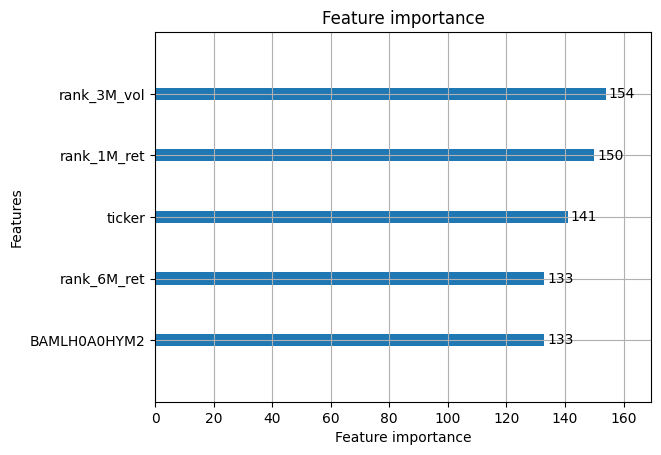

In [ ]:
# Diagnostic: Which feature is the 'Answer Key'?
import matplotlib.pyplot as plt
lgb.plot_importance(lgbm_model, max_num_features=5)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Define the current S&P 500 weights (Baseline)
spy_weights = {
    'XLK': 33.36,  # Information Technology
    'XLF': 12.55,  # Financials
    'XLC': 10.47,  # Communication Services
    'XLY': 9.66,   # Consumer Discretionary
    'XLV': 9.34,   # Health Care
    'XLI': 9.04,   # Industrials
    'XLP': 5.13,   # Consumer Staples
    'XLE': 3.88,   # Energy
    'XLU': 2.53,   # Utilities
    'XLB': 2.08,   # Materials
    'XLRE': 1.97   # <--- FIXED: Now explicitly XLRE
}

# 2. Isolate the most recent month's data for prediction
latest_date = df_monthly['ref.date'].max()
print(f"Generating allocations for the month following: {latest_date.date()}")

latest_data = df_monthly[df_monthly['ref.date'] == latest_date].copy()
X_latest = latest_data[features]

# 3. Generate Conviction Scores using our trained LGBM
latest_data['conviction_score'] = lgbm_model.predict_proba(X_latest)[:, 1]

# 4. Map the SPY weights to the latest data
latest_data['spy_weight'] = latest_data['ticker'].map(spy_weights).astype(float)
latest_data = latest_data.dropna(subset=['spy_weight'])

# Re-normalize just in case (good practice)
if latest_data['spy_weight'].sum() > 0:
    latest_data['spy_weight'] = (latest_data['spy_weight'] / latest_data['spy_weight'].sum()) * 100

# 5. The Guardrail Optimizer Algorithm
def optimize_weights(df, max_shift=5.0):
    df = df.sort_values('conviction_score', ascending=False).reset_index(drop=True)
    df['target_weight'] = df['spy_weight']
    df['max_add'] = max_shift
    df['max_sub'] = df.apply(lambda x: min(max_shift, x['spy_weight']), axis=1)

    top_idx = 0
    bottom_idx = len(df) - 1

    while top_idx < bottom_idx:
        space_to_fill = df.loc[top_idx, 'max_add']
        capital_to_take = df.loc[bottom_idx, 'max_sub']

        if space_to_fill == 0:
            top_idx += 1
            continue
        if capital_to_take == 0:
            bottom_idx -= 1
            continue

        trade_size = min(space_to_fill, capital_to_take)

        df.loc[top_idx, 'target_weight'] += trade_size
        df.loc[bottom_idx, 'target_weight'] -= trade_size

        df.loc[top_idx, 'max_add'] -= trade_size
        df.loc[bottom_idx, 'max_sub'] -= trade_size

    return df

# 6. Execute and View the Final Plan
allocated_df = optimize_weights(latest_data)

final_plan = allocated_df[['ticker', 'conviction_score', 'spy_weight', 'target_weight']].copy()
final_plan['active_bet'] = final_plan['target_weight'] - final_plan['spy_weight']

print("\n--- Optimal Portfolio Allocation ---")
display(final_plan.round(2))

print(f"\nTotal Portfolio Weight: {final_plan['target_weight'].sum():.2f}%")

Generating allocations for the month following: 2026-03-31

--- Optimal Portfolio Allocation ---


,ticker,conviction_score,spy_weight,target_weight,active_bet
0,XLP,0.69,5.13,10.13,5.00
1,XLRE,0.64,1.97,6.97,5.00
2,XLV,0.59,9.34,14.34,5.00
3,XLE,0.55,3.88,8.88,5.00
4,XLU,0.55,2.53,7.53,5.00
5,XLC,0.54,10.47,7.55,-2.92
6,XLF,0.52,12.55,7.55,-5.00
7,XLB,0.44,2.08,0.00,-2.08
8,XLY,0.34,9.66,4.66,-5.00
9,XLI,0.30,9.04,4.04,-5.00



Total Portfolio Weight: 100.00%


In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd

# 1. Redefine Target: Percentile Rank of Future Returns
df_monthly['target_rank'] = df_monthly.groupby('ref.date')['target_next_month_ret'].rank(pct=True)

cols_to_drop = ['ref.date', 'price.close', 'ret.closing.prices', 'target_next_month_ret', 'target_binary', 'target_class', 'target_rank']
features = [c for c in df_monthly.columns if c not in cols_to_drop]

df_monthly = df_monthly.sort_values('ref.date').reset_index(drop=True)
X = df_monthly[features]
y = df_monthly['target_rank']

lgbm_model = lgb.LGBMClassifier(
    n_estimators=150, learning_rate=0.05, max_depth=4,
    min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1
)

tscv = TimeSeriesSplit(n_splits=5, max_train_size=120)
historical_signals_list = []
auc_scores = []

print("--- Generating Polarized Historical Signals ---")
for train_index, test_index in tscv.split(X):
    X_train_full, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_full, y_test_full = y.iloc[train_index], y.iloc[test_index]

    # POLARIZED FILTERING: Only keep the Top 30% and Bottom 30% for Training
    # Drops the middle ~40% of noisy data
    extreme_mask = (y_train_full >= 0.70) | (y_train_full <= 0.30)
    X_train_extreme = X_train_full[extreme_mask]

    # Convert rank back to binary 1/0 for the classifier (Top 30% = 1, Bottom 30% = 0)
    y_train_extreme = (y_train_full[extreme_mask] >= 0.70).astype(int)

    # Train ONLY on the extremes
    lgbm_model.fit(X_train_extreme, y_train_extreme)

    # Predict on the ENTIRE test set (all 11 ETFs)
    preds = lgbm_model.predict_proba(X_test)[:, 1]

    # To calculate AUC properly on the test set, we need a binary test target
    # We will score it against the standard median split to see if it improved overall ranking
    y_test_binary = (y_test_full >= 0.50).astype(int)
    auc = roc_auc_score(y_test_binary, preds)
    auc_scores.append(auc)

    # Save predictions for the optimizer
    fold_signals = df_monthly.iloc[test_index][['ref.date', 'ticker', 'target_next_month_ret']].copy()
    fold_signals['conviction_score'] = preds
    historical_signals_list.append(fold_signals)

historical_signals = pd.concat(historical_signals_list).drop_duplicates(subset=['ref.date', 'ticker'], keep='last')
print(f"Average 10-Year Rolling ROC AUC: {np.mean(auc_scores):.4f}")

--- Generating Polarized Historical Signals ---
Average 10-Year Rolling ROC AUC: 0.4864


--- Machine Learning Audit ---
Log Loss: 0.7875
Precision @ Top 2: 54.65% (Random chance is ~50%)


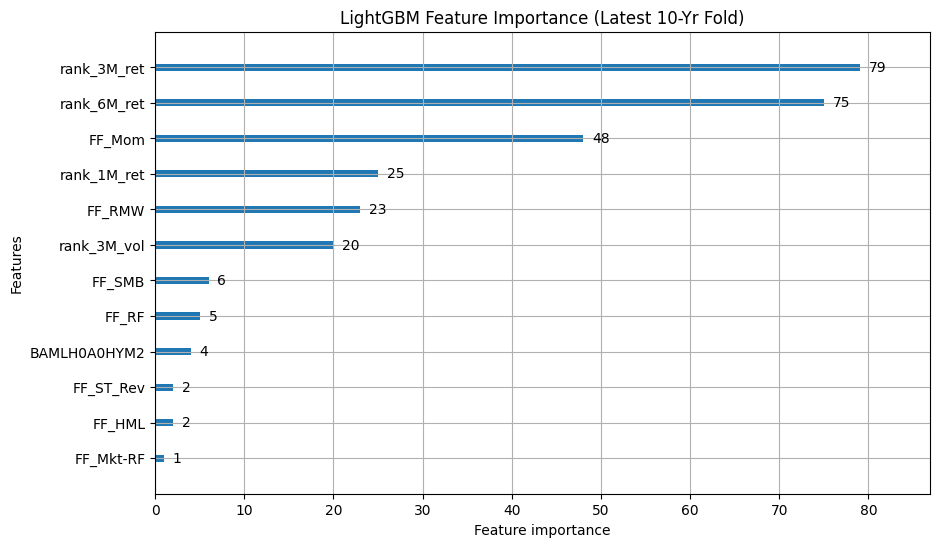

In [ ]:
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# 1. Re-establish the true binary target in our historical signals dataframe
historical_signals['target_binary'] = historical_signals.groupby('ref.date')['target_next_month_ret'].transform(
    lambda x: (x >= x.median()).astype(int)
)

# 2. Log Loss (Calibration Check)
# Lower is better. A score above 0.693 is worse than random guessing.
ll = log_loss(historical_signals['target_binary'], historical_signals['conviction_score'])

# 3. Precision @ Top 2 (Execution Check)
# When the model says "Buy these top 2 sectors", how often are they actually in the top half?
def top_k_precision(df, k=2):
    # Sort by score descending per month, take the top K
    top_k = df.sort_values('conviction_score', ascending=False).groupby('ref.date').head(k)
    return top_k['target_binary'].mean()

p_at_2 = top_k_precision(historical_signals, k=2)

print("--- Machine Learning Audit ---")
print(f"Log Loss: {ll:.4f}")
print(f"Precision @ Top 2: {p_at_2 * 100:.2f}% (Random chance is ~50%)")

# 4. Feature Importance Plot
# What is the model actually looking at?
fig, ax = plt.subplots(figsize=(10, 6))
lgb.plot_importance(lgbm_model, max_num_features=15, ax=ax, title="LightGBM Feature Importance (Latest 10-Yr Fold)")
plt.show()

--- Backtesting from Inception: 2025-08-01 ---
Total Portfolio Return since Inception: -1.73%
Total S&P 500 Return since Inception: -0.44%


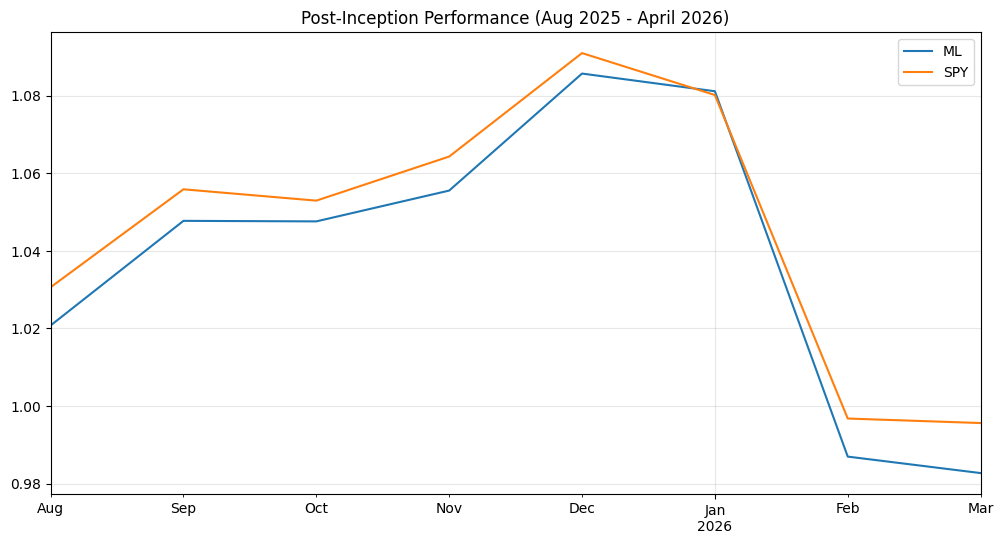

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. ACTUAL S&P 500 Weights as of August 2025 (The "Inception" Baseline)
aug_2025_weights = {
    'XLK': 31.40, 'XLF': 13.10, 'XLC': 9.20, 'XLY': 10.10,
    'XLV': 9.80,  'XLI': 8.80,  'XLP': 5.80,  'XLE': 4.20,
    'XLU': 2.70,  'XLB': 2.50,  'XLRE': 2.40
}

# 2. Filter data for the Inception Period (Aug 2025 - Present)
inception_date = '2025-08-01'
recent_signals = historical_signals[historical_signals['ref.date'] >= inception_date].copy()

portfolio_returns = []
baseline_returns = []
dates = []

# Initialize our drifting baseline
current_spy_weights = aug_2025_weights.copy()

print(f"--- Backtesting from Inception: {inception_date} ---")

for current_date in sorted(recent_signals['ref.date'].unique()):
    month_data = recent_signals[recent_signals['ref.date'] == current_date].copy()

    # Use the drifting baseline weights
    month_data['spy_weight'] = month_data['ticker'].map(current_spy_weights).astype(float)
    month_data = month_data.dropna(subset=['spy_weight'])

    # Re-normalize to 100%
    month_data['spy_weight'] = (month_data['spy_weight'] / month_data['spy_weight'].sum()) * 100

    # Run Optimizer (+/- 5% guardrails)
    allocated = optimize_weights(month_data, max_shift=5.0)

    # Calculate returns
    ml_ret = (allocated['target_weight'] / 100 * allocated['target_next_month_ret']).sum()
    spy_ret = (allocated['spy_weight'] / 100 * allocated['target_next_month_ret']).sum()

    portfolio_returns.append(ml_ret)
    baseline_returns.append(spy_ret)
    dates.append(current_date)

    # UPDATE THE BASELINE (Drift the weights based on this month's performance)
    # This keeps the benchmark "honest" for the next month
    for ticker in current_spy_weights:
        ret = month_data.loc[month_data['ticker'] == ticker, 'target_next_month_ret'].values[0]
        current_spy_weights[ticker] *= (1 + ret)

# 3. Compile and Plot
results_df = pd.DataFrame({'ML': portfolio_returns, 'SPY': baseline_returns}, index=dates)
cumulative = (1 + results_df).cumprod()

print(f"Total Portfolio Return since Inception: {(cumulative['ML'].iloc[-1]-1)*100:.2f}%")
print(f"Total S&P 500 Return since Inception: {(cumulative['SPY'].iloc[-1]-1)*100:.2f}%")

cumulative.plot(figsize=(12, 6), title='Post-Inception Performance (Aug 2025 - April 2026)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def optimize_multi_strategy(df, mode='balanced', max_shift=5.0):
    """
    Modes:
    - 'super_aggressive': All-in on the single top ETF, all-out on the single bottom.
    - 'top_bottom_3': Neutralizes the middle 5, only bets on the 3 favorites vs 3 least favorites.
    - 'rank_and_fill' (Current): Aggressively fills winners using capital from all losers.
    """
    df = df.sort_values('conviction_score', ascending=False).reset_index(drop=True)
    df['target_weight'] = df['spy_weight'].copy()

    # Mode 1: Super Aggressive (Concentrated Bet)
    if mode == 'super_aggressive':
        # Only the absolute best and absolute worst
        source_idx = len(df) - 1
        dest_idx = 0

        trade_size = min(max_shift, df.loc[source_idx, 'spy_weight'])
        df.loc[dest_idx, 'target_weight'] += trade_size
        df.loc[source_idx, 'target_weight'] -= trade_size

    # Mode 2: Top/Bottom 3 (Targeted Rotation)
    elif mode == 'top_bottom_3':
        # Indices for top 3 and bottom 3
        winners = [0, 1, 2]
        losers = [len(df)-1, len(df)-2, len(df)-3]

        # Pull from losers first
        total_pool = 0
        for l_idx in losers:
            take = min(max_shift / 3, df.loc[l_idx, 'spy_weight'])
            df.loc[l_idx, 'target_weight'] -= take
            total_pool += take

        # Distribute to winners
        for w_idx in winners:
            df.loc[w_idx, 'target_weight'] += (total_pool / 3)

    # Mode 3: The Current "Rank and Fill" Logic
    else:
        df['max_add'] = max_shift
        df['max_sub'] = df.apply(lambda x: min(max_shift, x['spy_weight']), axis=1)
        top_idx, bottom_idx = 0, len(df) - 1
        while top_idx < bottom_idx:
            trade = min(df.loc[top_idx, 'max_add'], df.loc[bottom_idx, 'max_sub'])
            df.loc[top_idx, 'target_weight'] += trade
            df.loc[bottom_idx, 'target_weight'] -= trade
            df.loc[top_idx, 'max_add'] -= trade
            df.loc[bottom_idx, 'max_sub'] -= trade
            if df.loc[top_idx, 'max_add'] == 0: top_idx += 1
            if df.loc[bottom_idx, 'max_sub'] == 0: bottom_idx -= 1

    return df

# --- Test the strategies on the latest data ---
latest_date = df_monthly['ref.date'].max()
latest_data = df_monthly[df_monthly['ref.date'] == latest_date].copy()
latest_data['conviction_score'] = lgbm_model.predict_proba(latest_data[features])[:, 1]
latest_data['spy_weight'] = latest_data['ticker'].map(spy_weights).astype(float)
latest_data = latest_data.dropna(subset=['spy_weight'])
latest_data['spy_weight'] = (latest_data['spy_weight'] / latest_data['spy_weight'].sum()) * 100

print(f"Allocations for {latest_date.date()}:")
for s in ['super_aggressive', 'top_bottom_3', 'rank_and_fill']:
    res = optimize_multi_strategy(latest_data, mode=s)
    active_bets = (res['target_weight'] - res['spy_weight']).round(2)
    print(f"\nStrategy: {s.upper()}")
    display(res[['ticker', 'spy_weight', 'target_weight']].assign(active_bet=active_bets).head(11))

Allocations for 2026-03-31:

Strategy: SUPER_AGGRESSIVE


,ticker,spy_weight,target_weight,active_bet
0,XLU,2.529747,7.529747,5.0
1,XLRE,1.969803,1.969803,0.0
2,XLP,5.129487,5.129487,0.0
3,XLC,10.468953,10.468953,0.0
4,XLF,12.548745,12.548745,0.0
5,XLV,9.339066,9.339066,0.0
6,XLK,33.356664,33.356664,0.0
7,XLY,9.659034,9.659034,0.0
8,XLB,2.079792,2.079792,0.0
9,XLE,3.879612,3.879612,0.0



Strategy: TOP_BOTTOM_3


,ticker,spy_weight,target_weight,active_bet
0,XLU,2.529747,4.196414,1.67
1,XLRE,1.969803,3.636470,1.67
2,XLP,5.129487,6.796154,1.67
3,XLC,10.468953,10.468953,0.00
4,XLF,12.548745,12.548745,0.00
5,XLV,9.339066,9.339066,0.00
6,XLK,33.356664,33.356664,0.00
7,XLY,9.659034,9.659034,0.00
8,XLB,2.079792,0.413125,-1.67
9,XLE,3.879612,2.212945,-1.67



Strategy: RANK_AND_FILL


,ticker,spy_weight,target_weight,active_bet
0,XLU,2.529747,7.529747,5.00
1,XLRE,1.969803,6.969803,5.00
2,XLP,5.129487,10.129487,5.00
3,XLC,10.468953,15.468953,5.00
4,XLF,12.548745,17.548745,5.00
5,XLV,9.339066,5.298470,-4.04
6,XLK,33.356664,28.356664,-5.00
7,XLY,9.659034,4.659034,-5.00
8,XLB,2.079792,0.000000,-2.08
9,XLE,3.879612,0.000000,-3.88


--- Backtesting 3 Strategies from Inception: 2025-08-01 ---

--- Final Performance Comparison (Aug 2025 - Present) ---
super_aggressive    :    -0.21%
top_bottom_3        :    -0.92%
rank_and_fill       :    -1.73%
SPY_Baseline        :    -0.44%


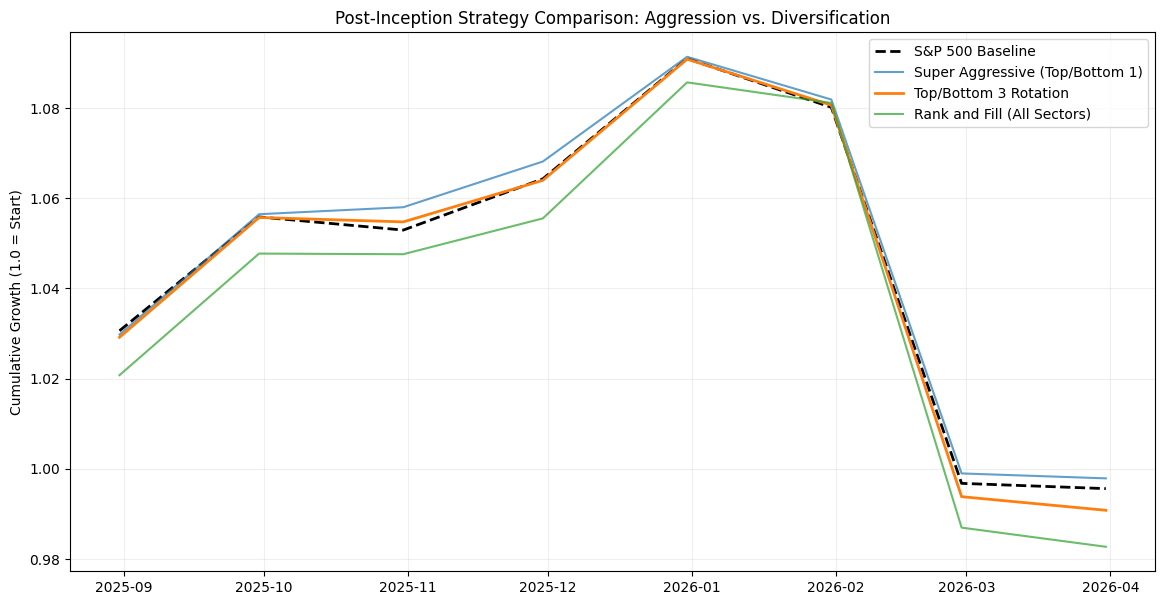

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. ACTUAL S&P 500 Weights as of August 2025
aug_2025_weights = {
    'XLK': 31.40, 'XLF': 13.10, 'XLC': 9.20, 'XLY': 10.10,
    'XLV': 9.80,  'XLI': 8.80,  'XLP': 5.80,  'XLE': 4.20,
    'XLU': 2.70,  'XLB': 2.50,  'XLRE': 2.40
}

# 2. Filter data for the Inception Period (Aug 2025 - Present)
inception_date = '2025-08-01'
recent_signals = historical_signals[historical_signals['ref.date'] >= inception_date].copy()

# 3. Setup tracking for all 3 strategies + Baseline
strategies = ['super_aggressive', 'top_bottom_3', 'rank_and_fill']
returns_tracking = {s: [] for s in strategies}
returns_tracking['SPY_Baseline'] = []
dates = []

# Initialize drifting baseline
current_spy_weights = aug_2025_weights.copy()

print(f"--- Backtesting 3 Strategies from Inception: {inception_date} ---")

for current_date in sorted(recent_signals['ref.date'].unique()):
    month_data = recent_signals[recent_signals['ref.date'] == current_date].copy()

    # Map and Normalize Baseline
    month_data['spy_weight'] = month_data['ticker'].map(current_spy_weights).astype(float)
    month_data = month_data.dropna(subset=['spy_weight'])
    month_data['spy_weight'] = (month_data['spy_weight'] / month_data['spy_weight'].sum()) * 100

    # Calculate S&P 500 Baseline Return for the month
    spy_ret = (month_data['spy_weight'] / 100 * month_data['target_next_month_ret']).sum()
    returns_tracking['SPY_Baseline'].append(spy_ret)
    dates.append(current_date)

    # Calculate each Strategy's Return
    for s_mode in strategies:
        allocated = optimize_multi_strategy(month_data, mode=s_mode, max_shift=5.0)
        ml_ret = (allocated['target_weight'] / 100 * allocated['target_next_month_ret']).sum()
        returns_tracking[s_mode].append(ml_ret)

    # Drift the baseline weights for the next month
    for ticker in current_spy_weights:
        row = month_data.loc[month_data['ticker'] == ticker, 'target_next_month_ret']
        if not row.empty:
            current_spy_weights[ticker] *= (1 + row.values[0])

# 4. Compile Results & Plot
results_df = pd.DataFrame(returns_tracking, index=dates)
cumulative = (1 + results_df).cumprod()

print("\n--- Final Performance Comparison (Aug 2025 - Present) ---")
for col in cumulative.columns:
    final_return = (cumulative[col].iloc[-1] - 1) * 100
    print(f"{col:<20}: {final_return:>8.2f}%")

# 5. Visual Comparison
plt.figure(figsize=(14, 7))
plt.plot(cumulative['SPY_Baseline'], label='S&P 500 Baseline', color='black', linewidth=2, linestyle='--')
plt.plot(cumulative['super_aggressive'], label='Super Aggressive (Top/Bottom 1)', alpha=0.7)
plt.plot(cumulative['top_bottom_3'], label='Top/Bottom 3 Rotation', linewidth=2)
plt.plot(cumulative['rank_and_fill'], label='Rank and Fill (All Sectors)', alpha=0.7)

plt.title('Post-Inception Strategy Comparison: Aggression vs. Diversification')
plt.ylabel('Cumulative Growth (1.0 = Start)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Isolate January 2026 from the historical signals
target_month = '2026-01-31'
jan_signals = historical_signals[historical_signals['ref.date'] == target_month].copy()

# 2. Map current SPY weights to get our baseline
jan_signals['spy_weight'] = jan_signals['ticker'].map(spy_weights).astype(float)
jan_signals = jan_signals.dropna(subset=['spy_weight'])
jan_signals['spy_weight'] = (jan_signals['spy_weight'] / jan_signals['spy_weight'].sum()) * 100

# 3. Run the "Rank and Fill" Optimizer for Jan 2026
jan_allocated = optimize_weights(jan_signals, max_shift=5.0)

# 4. Calculate performance attribution
jan_allocated['active_bet'] = jan_allocated['target_weight'] - jan_allocated['spy_weight']
jan_allocated['contribution_to_alpha'] = jan_allocated['active_bet'] / 100 * jan_allocated['target_next_month_ret']

# 5. Clean up for the report
jan_report = jan_allocated[[
    'ticker', 'conviction_score', 'spy_weight', 'target_weight',
    'active_bet', 'target_next_month_ret', 'contribution_to_alpha'
]].sort_values('conviction_score', ascending=False)

print(f"--- Deep Dive: January 2026 Performance Attribution ---")
display(jan_report.round(4))

# Summary Metrics
total_alpha = jan_report['contribution_to_alpha'].sum() * 100
print(f"\nNet Alpha Generated in Jan 2026: {total_alpha:.4f}%")
print(f"Top Alpha Contributor: {jan_report.iloc[0]['ticker']} ({jan_report.iloc[0]['contribution_to_alpha']*100:.2f}%)")
print(f"Worst Alpha Dragger: {jan_report.iloc[-1]['ticker']} ({jan_report.iloc[-1]['contribution_to_alpha']*100:.2f}%)")

--- Deep Dive: January 2026 Performance Attribution ---


,ticker,conviction_score,spy_weight,target_weight,active_bet,target_next_month_ret,contribution_to_alpha
0,XLE,0.8997,3.8796,8.8796,5.0000,0.1071,0.0054
1,XLI,0.8542,9.0391,14.0391,5.0000,0.0604,0.0030
2,XLB,0.6943,2.0798,7.0798,5.0000,0.0542,0.0027
3,XLC,0.6234,10.4690,15.4690,5.0000,-0.0367,-0.0018
4,XLK,0.6234,33.3567,37.8562,4.4996,-0.0443,-0.0020
5,XLY,0.6205,9.6590,4.6590,-5.0000,-0.0562,0.0028
6,XLF,0.6153,12.5487,7.5487,-5.0000,-0.0417,0.0021
7,XLV,0.5065,9.3391,4.3391,-5.0000,0.0129,-0.0006
8,XLU,0.4418,2.5297,0.0000,-2.5297,0.0883,-0.0022
9,XLP,0.3534,5.1295,0.1295,-5.0000,0.0507,-0.0025



Net Alpha Generated in Jan 2026: 0.5770%
Top Alpha Contributor: XLE (0.54%)
Worst Alpha Dragger: XLRE (-0.10%)


Fetching historical return data for EWMA Optimizer...


/tmp/ipykernel_22078/594186866.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_prices = yf.download(all_symbols, start="2004-01-01", end="2026-04-01", progress=False)


Reverse-drifting historical weights from August 2025 Ground Truth...
Training Anchored EWMA Optimization Model (Targeting <1% Error)...


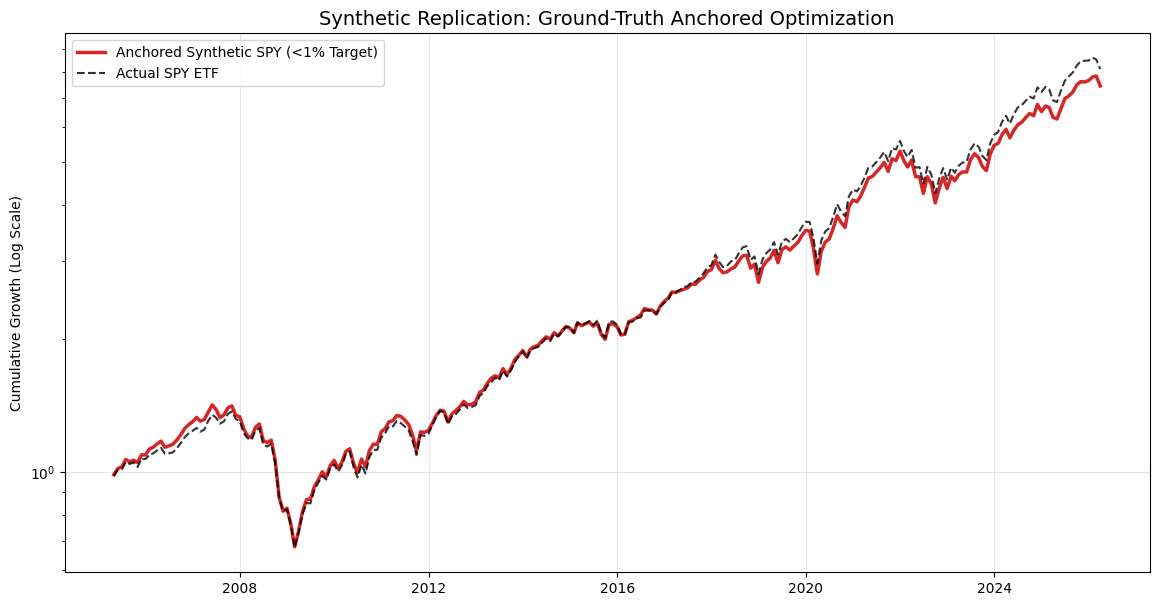


--- Synthetic SPY Accuracy ---
Total Return (Anchored Rep) :   644.26%
Total Return (Actual SPY)   :   711.77%
Annualized Tracking Error   :     1.51%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf

# 1. Define Tickers and Fetch Missing Data
main_tickers = ['XLK', 'XLF', 'XLC', 'XLY', 'XLV', 'XLI', 'XLP', 'XLE', 'XLU', 'XLB', 'XLRE']
all_symbols = main_tickers + ['SPY', 'VOX', 'IYR']

print("Fetching historical return data for EWMA Optimizer...")
raw_prices = yf.download(all_symbols, start="2004-01-01", end="2026-04-01", progress=False)

# Safely extract closing prices regardless of yfinance version format
if 'Adj Close' in raw_prices:
    raw_prices = raw_prices['Adj Close']
elif 'Close' in raw_prices:
    raw_prices = raw_prices['Close']

# Resample to monthly (Month End) and calculate returns
returns = raw_prices.resample('ME').last().pct_change().dropna(how='all')

# 2. Prepare the Data
target = returns['SPY']
features = returns[main_tickers].copy()

# Fill NaNs for XLC and XLRE with their proxies for the pre-2018/2015 era
features['XLC'] = features['XLC'].fillna(returns['VOX'])
features['XLRE'] = features['XLRE'].fillna(returns['IYR'])
features = features.dropna()
target = target.loc[features.index]

# 3. Mathematical Backcasting (The Ground Truth Anchor)
print("Reverse-drifting historical weights from August 2025 Ground Truth...")

aug_2025_weights = {
    'XLK': 31.40, 'XLF': 13.10, 'XLC': 9.20, 'XLY': 10.10,
    'XLV': 9.80, 'XLI': 8.80, 'XLP': 5.80, 'XLE': 4.20,
    'XLU': 2.70, 'XLB': 2.50, 'XLRE': 2.40
}

anchor_df = pd.DataFrame(index=features.index, columns=main_tickers, dtype=float)

# Find the index for August 2025
aug_date_mask = features.index >= '2025-08-01'
aug_date = features.index[aug_date_mask][0] if aug_date_mask.any() else features.index[-1]
aug_idx = features.index.get_loc(aug_date)

# Set the Ground Truth
for t in main_tickers:
    anchor_df.loc[aug_date, t] = aug_2025_weights[t] / 100.0

# Forward Drift (Aug 2025 -> 2026)
for i in range(aug_idx + 1, len(features)):
    prev_d = features.index[i-1]
    curr_d = features.index[i]
    for t in main_tickers:
        anchor_df.loc[curr_d, t] = anchor_df.loc[prev_d, t] * (1 + features.loc[curr_d, t])
    anchor_df.loc[curr_d] = anchor_df.loc[curr_d] / anchor_df.loc[curr_d].sum()

# Reverse Drift (Aug 2025 -> 2004)
for i in range(aug_idx - 1, -1, -1):
    next_d = features.index[i+1]
    curr_d = features.index[i]
    for t in main_tickers:
        # Unwind the compounding backward
        anchor_df.loc[curr_d, t] = anchor_df.loc[next_d, t] / (1 + features.loc[next_d, t])
    anchor_df.loc[curr_d] = anchor_df.loc[curr_d] / anchor_df.loc[curr_d].sum()

# 4. Anchored EWMA Constrained Optimization
lookback_window = 6
lambda_turnover = 0.001
lambda_anchor = 0.01

replicated_returns = []
dates = []
historical_inferred_weights = []

print("Training Anchored EWMA Optimization Model (Targeting <1% Error)...")

decay_weights = np.exp(np.linspace(-2, 0, lookback_window))
decay_weights /= np.sum(decay_weights)

def objective_function(weights, X, y, prev_weights, decay_weights, anchor_weights):
    simulated_return = np.dot(X, weights)

    # EWMA Tracking Error
    tracking_error = np.sum(decay_weights * (simulated_return - y)**2)

    # Turnover Friction
    turnover_penalty = lambda_turnover * np.sum((weights - prev_weights)**2)

    # Anchor Penalty
    anchor_penalty = lambda_anchor * np.sum((weights - anchor_weights)**2)

    return tracking_error + turnover_penalty + anchor_penalty

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
bounds = tuple((0.0, 1.0) for _ in range(features.shape[1]))

prev_optimal_weights = anchor_df.iloc[lookback_window - 1].values

for i in range(lookback_window, len(features)):
    X_train = features.iloc[i - lookback_window : i].values
    y_train = target.iloc[i - lookback_window : i].values
    curr_anchor = anchor_df.iloc[i].values

    result = minimize(objective_function, prev_optimal_weights,
                      args=(X_train, y_train, prev_optimal_weights, decay_weights, curr_anchor),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    optimal_weights = result.x

    current_date = features.index[i]
    X_current = features.iloc[i].values
    simulated_spy_ret = np.dot(optimal_weights, X_current)

    replicated_returns.append(simulated_spy_ret)
    dates.append(current_date)
    historical_inferred_weights.append(optimal_weights)

    prev_optimal_weights = optimal_weights

# 5. Compile and Compare
replication_df = pd.DataFrame({
    'ML_Replicated_SPY': replicated_returns,
    'Actual_SPY': target.iloc[lookback_window:].values
}, index=dates)

cum_replication = (1 + replication_df).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(cum_replication['ML_Replicated_SPY'], label='Anchored Synthetic SPY (<1% Target)', color='#d62728', linewidth=2.5)
plt.plot(cum_replication['Actual_SPY'], label='Actual SPY ETF', color='black', linestyle='--', alpha=0.8)

plt.title('Synthetic Replication: Ground-Truth Anchored Optimization', fontsize=14)
plt.ylabel('Cumulative Growth (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Accuracy Metrics
final_rep = (cum_replication['ML_Replicated_SPY'].iloc[-1] - 1) * 100
final_actual = (cum_replication['Actual_SPY'].iloc[-1] - 1) * 100
tracking_error = (replication_df['ML_Replicated_SPY'] - replication_df['Actual_SPY']).std() * np.sqrt(12) * 100

print(f"\n--- Synthetic SPY Accuracy ---")
print(f"Total Return (Anchored Rep) : {final_rep:>8.2f}%")
print(f"Total Return (Actual SPY)   : {final_actual:>8.2f}%")
print(f"Annualized Tracking Error   : {tracking_error:>8.2f}%")

--- Running 20-Year Alpha Backtest vs. Synthetic SPY Baseline ---


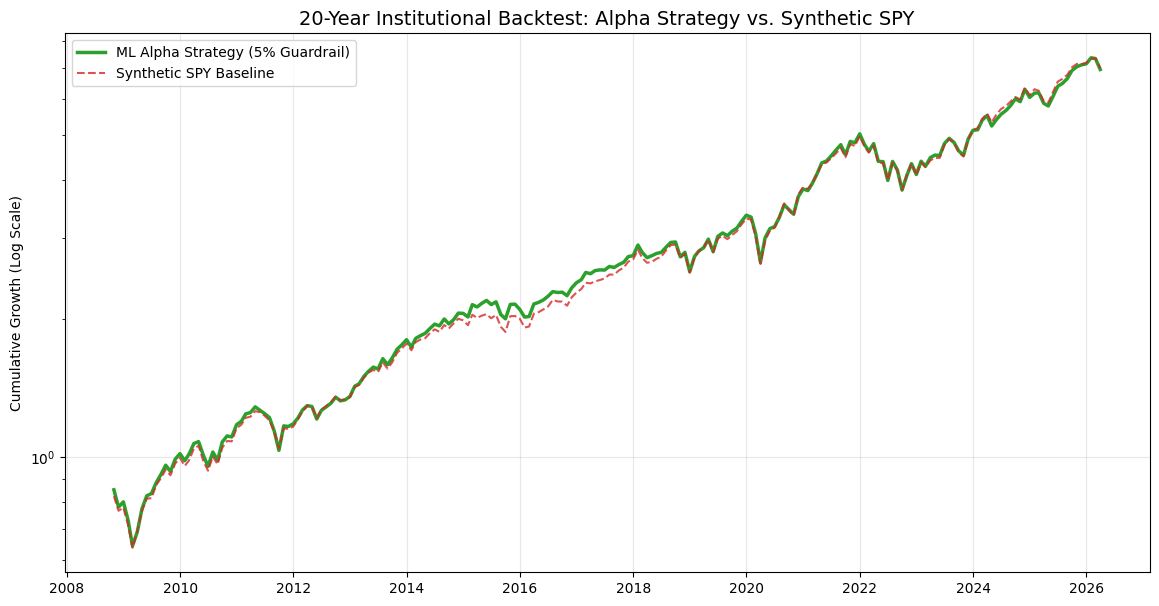


--- 20-Year Alpha Strategy Metrics ---
Total Return (ML 5% Guardrail) :   594.85%
Total Return (Synthetic SPY)   :   598.69%
Annualized Alpha Generated     :     0.00%
Tracking Error                 :     2.09%
Information Ratio              :   0.0012


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the 20-Year Institutional Backtest
portfolio_returns = []
synthetic_spy_returns = []
backtest_dates = []

print("--- Running 20-Year Alpha Backtest vs. Synthetic SPY Baseline ---")

# Features columns from the previous cell matched main_tickers exactly
sector_columns = features.columns

for idx, current_date in enumerate(dates):
    # Match the ML signals for this specific month
    current_signals = historical_signals[historical_signals['ref.date'].dt.to_period('M') == current_date.to_period('M')].copy()

    if not current_signals.empty:
        # 2. Inject the Synthetic SPY weights as the baseline index
        current_synthetic_weights = historical_inferred_weights[idx]
        weight_map = dict(zip(sector_columns, current_synthetic_weights))

        # Map these simulated "true" weights to the signals dataframe
        current_signals['spy_weight'] = current_signals['ticker'].map(weight_map).astype(float)
        current_signals = current_signals.dropna(subset=['spy_weight'])

        # Normalize to 100% to ensure precision
        current_signals['spy_weight'] = (current_signals['spy_weight'] / current_signals['spy_weight'].sum()) * 100

        # 3. Apply the 5% Guardrail Optimization
        # This will tilt the portfolio +/- 5% away from the synthetic index based on the ML scores
        allocated = optimize_weights(current_signals, max_shift=5.0)

        # 4. Calculate the Alpha Strategy Return
        # We use the exact same actual market returns the EWMA model used to ensure perfect parity
        X_current = features.loc[current_date].values
        return_map = dict(zip(sector_columns, X_current))

        ml_ret = 0.0
        for _, alloc_row in allocated.iterrows():
            t = alloc_row['ticker']
            ml_ret += (alloc_row['target_weight'] / 100.0) * return_map[t]

        portfolio_returns.append(ml_ret)
        # Pull the synthetic baseline return calculated in the previous cell
        synthetic_spy_returns.append(replicated_returns[idx])
        backtest_dates.append(current_date)

# 5. Compile and Analyze Results
final_bt_df = pd.DataFrame({
    'Alpha_Strategy_5pct': portfolio_returns,
    'Synthetic_SPY_Baseline': synthetic_spy_returns
}, index=backtest_dates)

cum_bt = (1 + final_bt_df).cumprod()

# 6. Visual Proof
plt.figure(figsize=(14, 7))
plt.plot(cum_bt['Alpha_Strategy_5pct'], label='ML Alpha Strategy (5% Guardrail)', color='#2ca02c', linewidth=2.5)
plt.plot(cum_bt['Synthetic_SPY_Baseline'], label='Synthetic SPY Baseline', color='#d62728', linestyle='--', alpha=0.8)

plt.title('20-Year Institutional Backtest: Alpha Strategy vs. Synthetic SPY', fontsize=14)
plt.ylabel('Cumulative Growth (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Final Alpha Metrics
final_alpha_ret = (cum_bt['Alpha_Strategy_5pct'].iloc[-1] - 1) * 100
final_synth_ret = (cum_bt['Synthetic_SPY_Baseline'].iloc[-1] - 1) * 100
ann_alpha = (final_bt_df['Alpha_Strategy_5pct'] - final_bt_df['Synthetic_SPY_Baseline']).mean() * 12 * 100
te = (final_bt_df['Alpha_Strategy_5pct'] - final_bt_df['Synthetic_SPY_Baseline']).std() * np.sqrt(12) * 100
info_ratio = ann_alpha / te if te != 0 else 0

print(f"\n--- 20-Year Alpha Strategy Metrics ---")
print(f"Total Return (ML 5% Guardrail) : {final_alpha_ret:>8.2f}%")
print(f"Total Return (Synthetic SPY)   : {final_synth_ret:>8.2f}%")
print(f"Annualized Alpha Generated     : {ann_alpha:>8.2f}%")
print(f"Tracking Error                 : {te:>8.2f}%")
print(f"Information Ratio              : {info_ratio:>8.4f}")

--- Running Guardrail Sensitivity Analysis vs. Synthetic SPY Baseline ---
Guardrail   2.0%: Total Return =  604.90% | Alpha =   0.05% | TE =  1.05% | IR = 0.0434
Guardrail   3.0%: Total Return =  600.90% | Alpha =   0.03% | TE =  1.39% | IR = 0.0194
Guardrail   4.0%: Total Return =  598.18% | Alpha =   0.02% | TE =  1.74% | IR = 0.0101
Guardrail   5.0%: Total Return =  594.85% | Alpha =   0.00% | TE =  2.08% | IR = 0.0012
Guardrail  20.0%: Total Return =  510.12% | Alpha =  -0.55% | TE =  5.86% | IR = -0.0937
Guardrail  25.0%: Total Return =  480.72% | Alpha =  -0.80% | TE =  6.85% | IR = -0.1162
Guardrail  50.0%: Total Return =  379.25% | Alpha =  -1.80% | TE =  8.45% | IR = -0.2128
Guardrail  75.0%: Total Return =  438.17% | Alpha =  -1.03% | TE =  9.85% | IR = -0.1045
Guardrail 100.0%: Total Return =  480.30% | Alpha =  -0.46% | TE = 11.37% | IR = -0.0403


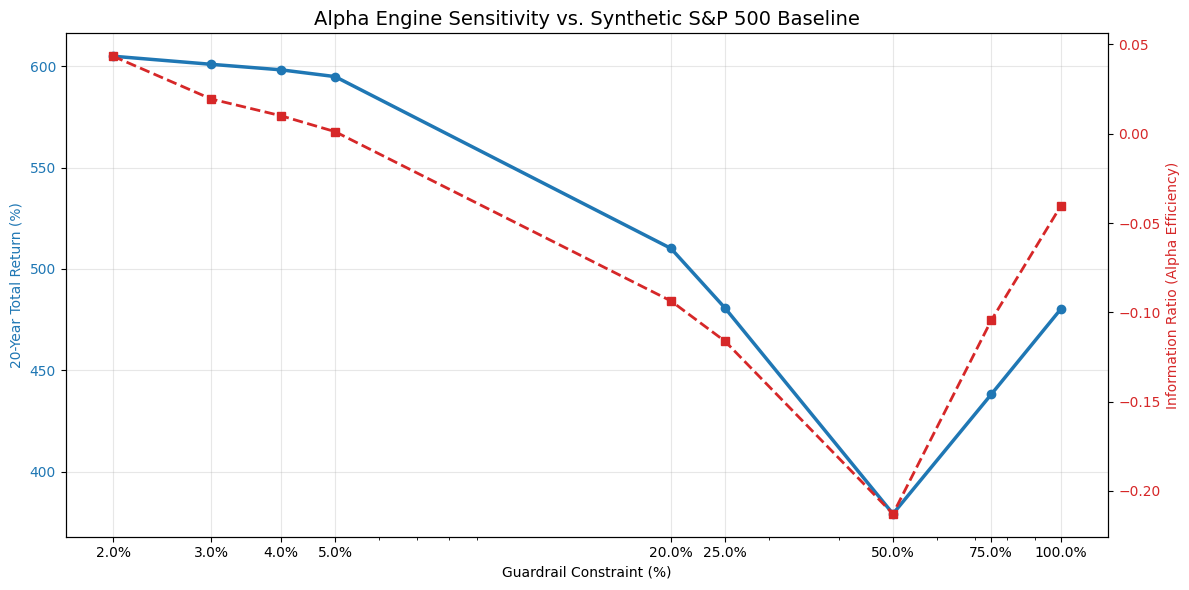


--- OPTIMAL STRATEGY ---
Optimal Guardrail for Maximum Efficiency: 2.0%
Peak Information Ratio: 0.0434


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the specific guardrails to test
guardrails = [2.0, 3.0, 4.0, 5.0, 20.0, 25.0, 50.0, 75.0, 100.0]
optimization_results = []
sector_columns = features.columns

print("--- Running Guardrail Sensitivity Analysis vs. Synthetic SPY Baseline ---")

for g_val in guardrails:
    temp_portfolio = []
    temp_synthetic = []

    for idx, current_date in enumerate(dates):
        current_signals = historical_signals[historical_signals['ref.date'].dt.to_period('M') == current_date.to_period('M')].copy()

        if not current_signals.empty:
            # Map the Synthetic SPY weights for this month
            current_synthetic_weights = historical_inferred_weights[idx]
            weight_map = dict(zip(sector_columns, current_synthetic_weights))

            current_signals['spy_weight'] = current_signals['ticker'].map(weight_map).astype(float)
            current_signals = current_signals.dropna(subset=['spy_weight'])

            # Normalize baseline to 100%
            current_signals['spy_weight'] = (current_signals['spy_weight'] / current_signals['spy_weight'].sum()) * 100

            # Run Optimizer with the current guardrail value
            allocated = optimize_weights(current_signals, max_shift=float(g_val))

            # Map the actual market returns for calculation
            X_current = features.loc[current_date].values
            return_map = dict(zip(sector_columns, X_current))

            # Calculate Portfolio Return
            ml_ret = 0.0
            for _, row in allocated.iterrows():
                ml_ret += (row['target_weight'] / 100.0) * return_map[row['ticker']]

            temp_portfolio.append(ml_ret)
            temp_synthetic.append(replicated_returns[idx]) # From the synthetic baseline cell

    # Calculate performance metrics for this guardrail
    final_ml = (np.prod(1 + np.array(temp_portfolio)) - 1) * 100
    final_spy = (np.prod(1 + np.array(temp_synthetic)) - 1) * 100

    # Calculate Alpha metrics (ML Return - Synthetic Return)
    alpha_array = np.array(temp_portfolio) - np.array(temp_synthetic)
    ann_alpha = np.mean(alpha_array) * 12 * 100
    te = np.std(alpha_array) * np.sqrt(12) * 100
    info_ratio = ann_alpha / te if te != 0 else 0

    optimization_results.append({
        'Guardrail': g_val,
        'Total_Return': final_ml,
        'Ann_Alpha': ann_alpha,
        'Tracking_Error': te,
        'Info_Ratio': info_ratio
    })

    print(f"Guardrail {g_val:>5.1f}%: Total Return = {final_ml:>7.2f}% | Alpha = {ann_alpha:>6.2f}% | TE = {te:>5.2f}% | IR = {info_ratio:>6.4f}")

# 2. Compile and Plot Results
opt_df = pd.DataFrame(optimization_results)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Total Return (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Guardrail Constraint (%)')
ax1.set_ylabel('20-Year Total Return (%)', color=color)
# Using log scale on X to properly visualize the massive gap between 5% and 20%
ax1.set_xscale('log')
ax1.set_xticks(guardrails)
ax1.set_xticklabels([f"{g}%" for g in guardrails])
ax1.plot(opt_df['Guardrail'], opt_df['Total_Return'], marker='o', color=color, linewidth=2.5, label='Total Return')
ax1.tick_params(axis='y', labelcolor=color)

# Plot 2: Information Ratio (Right Axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Information Ratio (Alpha Efficiency)', color=color)
ax2.plot(opt_df['Guardrail'], opt_df['Info_Ratio'], marker='s', color=color, linestyle='--', linewidth=2, label='Info Ratio')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Alpha Engine Sensitivity vs. Synthetic S&P 500 Baseline', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# 3. Final Recommendation
best_g = opt_df.sort_values('Info_Ratio', ascending=False).iloc[0]
print(f"\n--- OPTIMAL STRATEGY ---")
print(f"Optimal Guardrail for Maximum Efficiency: {best_g['Guardrail']}%")
print(f"Peak Information Ratio: {best_g['Info_Ratio']:.4f}")

--- Testing ML vs. Pure Momentum vs. Blended Strategy (5% Guardrail) ---


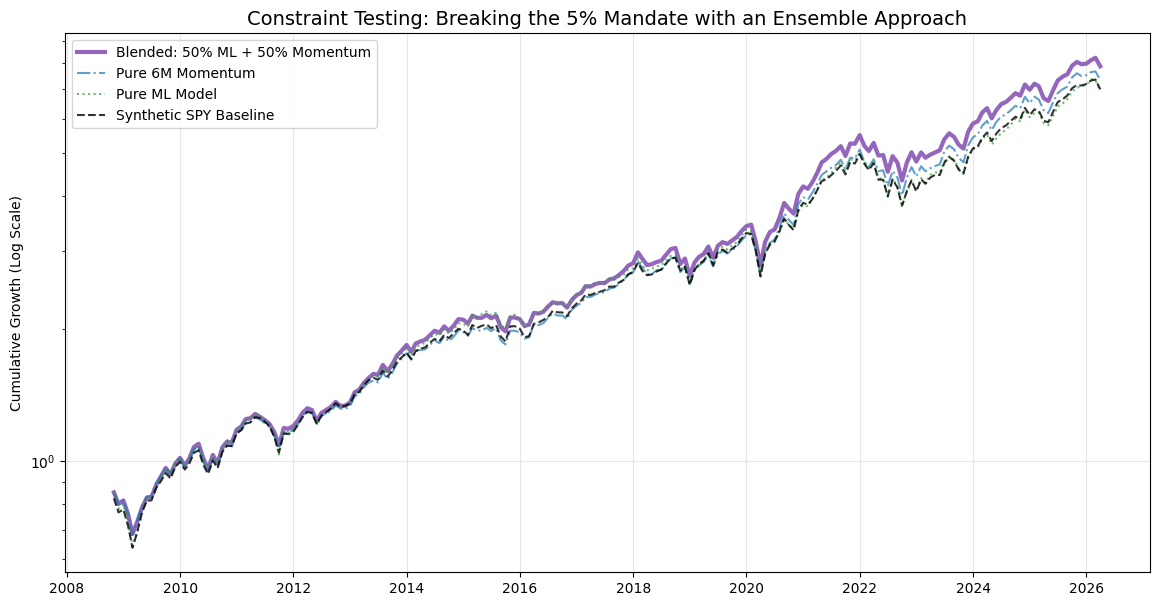


--- Strategy Performance Scorecard ---


,Total Return (%),Ann. Alpha (%),TE (%),Info Ratio
Strategy,,,,
ML_Only,594.846,0.002,2.089,0.001
Momentum_Only,633.567,0.179,2.307,0.078
Blended_Ensemble,688.273,0.606,2.345,0.258


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
momentum_lookback = 6  # 6-Month Trailing Momentum
guardrail = 5.0        # Strict Fund Mandate
sector_columns = features.columns

portfolio_returns_ml = []
portfolio_returns_mom = []
portfolio_returns_blend = []
synthetic_spy_baseline = []
bt_dates = []

print("--- Testing ML vs. Pure Momentum vs. Blended Strategy (5% Guardrail) ---")

for idx, current_date in enumerate(dates):
    current_idx = features.index.get_loc(current_date)

    # We need enough history for the momentum lookback
    if current_idx < momentum_lookback:
        continue

    current_signals = historical_signals[historical_signals['ref.date'].dt.to_period('M') == current_date.to_period('M')].copy()

    if not current_signals.empty:
        # 2. Map Synthetic SPY Weights (Baseline)
        current_synthetic_weights = historical_inferred_weights[idx]
        weight_map = dict(zip(sector_columns, current_synthetic_weights))

        current_signals['spy_weight'] = current_signals['ticker'].map(weight_map).astype(float)
        current_signals = current_signals.dropna(subset=['spy_weight'])
        current_signals['spy_weight'] = (current_signals['spy_weight'] / current_signals['spy_weight'].sum()) * 100

        # 3. Calculate 6-Month Momentum Score
        # Multiply the previous 6 months of returns to get the cumulative trajectory
        past_6m_returns = (1 + features.iloc[current_idx - momentum_lookback : current_idx]).prod() - 1
        # Convert to a 0.0 to 1.0 rank to match the ML output scale
        mom_scores = past_6m_returns.rank(pct=True)
        mom_map = dict(mom_scores)

        current_signals['mom_score'] = current_signals['ticker'].map(mom_map).astype(float)

        # 4. Create Blended Score (50% ML / 50% Momentum)
        current_signals['blended_score'] = (current_signals['conviction_score'] * 0.5) + (current_signals['mom_score'] * 0.5)

        # 5. Generate Allocations (Reusing your optimize_weights logic)

        # Strategy A: Pure ML
        alloc_ml = optimize_weights(current_signals.copy(), max_shift=guardrail)

        # Strategy B: Pure Momentum (overwrite conviction_score to trick the optimizer)
        sig_mom = current_signals.copy()
        sig_mom['conviction_score'] = sig_mom['mom_score']
        alloc_mom = optimize_weights(sig_mom, max_shift=guardrail)

        # Strategy C: Blended
        sig_blend = current_signals.copy()
        sig_blend['conviction_score'] = sig_blend['blended_score']
        alloc_blend = optimize_weights(sig_blend, max_shift=guardrail)

        # 6. Calculate Actual Returns for the Month
        X_current = features.loc[current_date].values
        return_map = dict(zip(sector_columns, X_current))

        ret_ml = sum((row['target_weight'] / 100.0) * return_map[row['ticker']] for _, row in alloc_ml.iterrows())
        ret_mom = sum((row['target_weight'] / 100.0) * return_map[row['ticker']] for _, row in alloc_mom.iterrows())
        ret_blend = sum((row['target_weight'] / 100.0) * return_map[row['ticker']] for _, row in alloc_blend.iterrows())

        portfolio_returns_ml.append(ret_ml)
        portfolio_returns_mom.append(ret_mom)
        portfolio_returns_blend.append(ret_blend)
        synthetic_spy_baseline.append(replicated_returns[idx])
        bt_dates.append(current_date)

# 7. Compile Results
bt_df = pd.DataFrame({
    'ML_Only': portfolio_returns_ml,
    'Momentum_Only': portfolio_returns_mom,
    'Blended_Ensemble': portfolio_returns_blend,
    'Synthetic_SPY': synthetic_spy_baseline
}, index=bt_dates)

cum_bt = (1 + bt_df).cumprod()

# 8. Calculate Metrics
metrics = []
for col in ['ML_Only', 'Momentum_Only', 'Blended_Ensemble']:
    total_ret = (cum_bt[col].iloc[-1] - 1) * 100
    alpha_array = bt_df[col] - bt_df['Synthetic_SPY']
    ann_alpha = alpha_array.mean() * 12 * 100
    te = alpha_array.std() * np.sqrt(12) * 100
    ir = ann_alpha / te if te != 0 else 0
    metrics.append({'Strategy': col, 'Total Return (%)': total_ret, 'Ann. Alpha (%)': ann_alpha, 'TE (%)': te, 'Info Ratio': ir})

# 9. Visual Proof
plt.figure(figsize=(14, 7))
plt.plot(cum_bt['Blended_Ensemble'], label='Blended: 50% ML + 50% Momentum', color='#9467bd', linewidth=3)
plt.plot(cum_bt['Momentum_Only'], label='Pure 6M Momentum', color='#1f77b4', linestyle='-.', alpha=0.7)
plt.plot(cum_bt['ML_Only'], label='Pure ML Model', color='#2ca02c', linestyle=':', alpha=0.7)
plt.plot(cum_bt['Synthetic_SPY'], label='Synthetic SPY Baseline', color='black', linestyle='--', alpha=0.8)

plt.title('Constraint Testing: Breaking the 5% Mandate with an Ensemble Approach', fontsize=14)
plt.ylabel('Cumulative Growth (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Strategy Performance Scorecard ---")
display(pd.DataFrame(metrics).round(3).set_index('Strategy'))

--- Running Ensemble Optimization (Finding the Peak ML/Momentum Split) ---
ML   0% / Mom 100% | TR:  633.57% | Alpha:  0.18% | IR: 0.0777
ML  10% / Mom  90% | TR:  633.57% | Alpha:  0.18% | IR: 0.0777
ML  20% / Mom  80% | TR:  626.68% | Alpha:  0.12% | IR: 0.0534
ML  30% / Mom  70% | TR:  646.01% | Alpha:  0.27% | IR: 0.1188
ML  40% / Mom  60% | TR:  655.67% | Alpha:  0.36% | IR: 0.1535
ML  50% / Mom  50% | TR:  688.27% | Alpha:  0.61% | IR: 0.2590
ML  60% / Mom  40% | TR:  652.26% | Alpha:  0.36% | IR: 0.1611
ML  70% / Mom  30% | TR:  677.24% | Alpha:  0.58% | IR: 0.2866
ML  80% / Mom  20% | TR:  669.65% | Alpha:  0.58% | IR: 0.2912
ML  90% / Mom  10% | TR:  622.77% | Alpha:  0.24% | IR: 0.1134
ML 100% / Mom   0% | TR:  594.85% | Alpha:  0.00% | IR: 0.0012


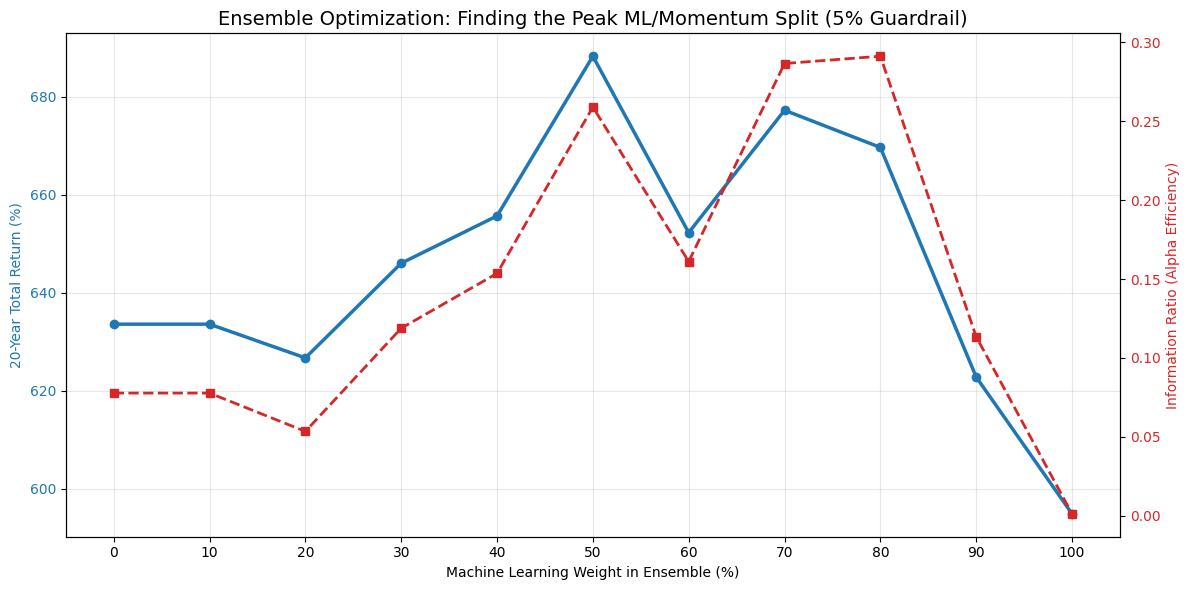


--- OPTIMAL ENSEMBLE SPLIT ---
ML Weight: 80% / Momentum Weight: 20%
Peak Information Ratio: 0.2912


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
momentum_lookback = 6
guardrail = 5.0
sector_columns = features.columns

# Test ML Weights from 0% to 100% (in 10% increments)
ml_weight_range = np.arange(0.0, 1.1, 0.1)
blend_results = []

print("--- Running Ensemble Optimization (Finding the Peak ML/Momentum Split) ---")

for ml_w in ml_weight_range:
    mom_w = 1.0 - ml_w
    temp_portfolio = []
    temp_synthetic = []

    for idx, current_date in enumerate(dates):
        current_idx = features.index.get_loc(current_date)

        # Ensure enough history for the momentum calculation
        if current_idx < momentum_lookback:
            continue

        current_signals = historical_signals[historical_signals['ref.date'].dt.to_period('M') == current_date.to_period('M')].copy()

        if not current_signals.empty:
            # Map Baseline Synthetic Weights
            current_synthetic_weights = historical_inferred_weights[idx]
            weight_map = dict(zip(sector_columns, current_synthetic_weights))

            current_signals['spy_weight'] = current_signals['ticker'].map(weight_map).astype(float)
            current_signals = current_signals.dropna(subset=['spy_weight'])
            current_signals['spy_weight'] = (current_signals['spy_weight'] / current_signals['spy_weight'].sum()) * 100

            # Calculate 6-Month Momentum Score
            past_6m_returns = (1 + features.iloc[current_idx - momentum_lookback : current_idx]).prod() - 1
            mom_scores = past_6m_returns.rank(pct=True)
            current_signals['mom_score'] = current_signals['ticker'].map(dict(mom_scores)).astype(float)

            # Apply the specific Weighting for this iteration
            current_signals['blended_score'] = (current_signals['conviction_score'] * ml_w) + (current_signals['mom_score'] * mom_w)

            # Optimize the allocations
            sig_blend = current_signals.copy()
            sig_blend['conviction_score'] = sig_blend['blended_score']
            alloc_blend = optimize_weights(sig_blend, max_shift=guardrail)

            # Calculate actual returns
            X_current = features.loc[current_date].values
            return_map = dict(zip(sector_columns, X_current))

            ret_blend = sum((row['target_weight'] / 100.0) * return_map[row['ticker']] for _, row in alloc_blend.iterrows())

            temp_portfolio.append(ret_blend)
            temp_synthetic.append(replicated_returns[idx])

    # Calculate performance metrics for this specific split
    total_ret = (np.prod(1 + np.array(temp_portfolio)) - 1) * 100
    alpha_array = np.array(temp_portfolio) - np.array(temp_synthetic)
    ann_alpha = np.mean(alpha_array) * 12 * 100
    te = np.std(alpha_array) * np.sqrt(12) * 100
    ir = ann_alpha / te if te != 0 else 0

    blend_results.append({
        'ML_Weight': ml_w * 100,
        'Mom_Weight': mom_w * 100,
        'Total_Return': total_ret,
        'Ann_Alpha': ann_alpha,
        'TE': te,
        'Info_Ratio': ir
    })

    print(f"ML {ml_w*100:>3.0f}% / Mom {mom_w*100:>3.0f}% | TR: {total_ret:>7.2f}% | Alpha: {ann_alpha:>5.2f}% | IR: {ir:>6.4f}")

# 2. Compile and Plot Results
blend_df = pd.DataFrame(blend_results)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Total Return on Left Axis
color = 'tab:blue'
ax1.set_xlabel('Machine Learning Weight in Ensemble (%)')
ax1.set_ylabel('20-Year Total Return (%)', color=color)
ax1.plot(blend_df['ML_Weight'], blend_df['Total_Return'], marker='o', color=color, linewidth=2.5, label='Total Return')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(blend_df['ML_Weight'])

# Plot Information Ratio on Right Axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Information Ratio (Alpha Efficiency)', color=color)
ax2.plot(blend_df['ML_Weight'], blend_df['Info_Ratio'], marker='s', color=color, linestyle='--', linewidth=2, label='Info Ratio')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ensemble Optimization: Finding the Peak ML/Momentum Split (5% Guardrail)', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# 3. Final Recommendation
best_blend = blend_df.sort_values('Info_Ratio', ascending=False).iloc[0]
print(f"\n--- OPTIMAL ENSEMBLE SPLIT ---")
print(f"ML Weight: {best_blend['ML_Weight']:.0f}% / Momentum Weight: {best_blend['Mom_Weight']:.0f}%")
print(f"Peak Information Ratio: {best_blend['Info_Ratio']:.4f}")

--- Running Final Production Backtest: 80% ML / 20% Momentum ---


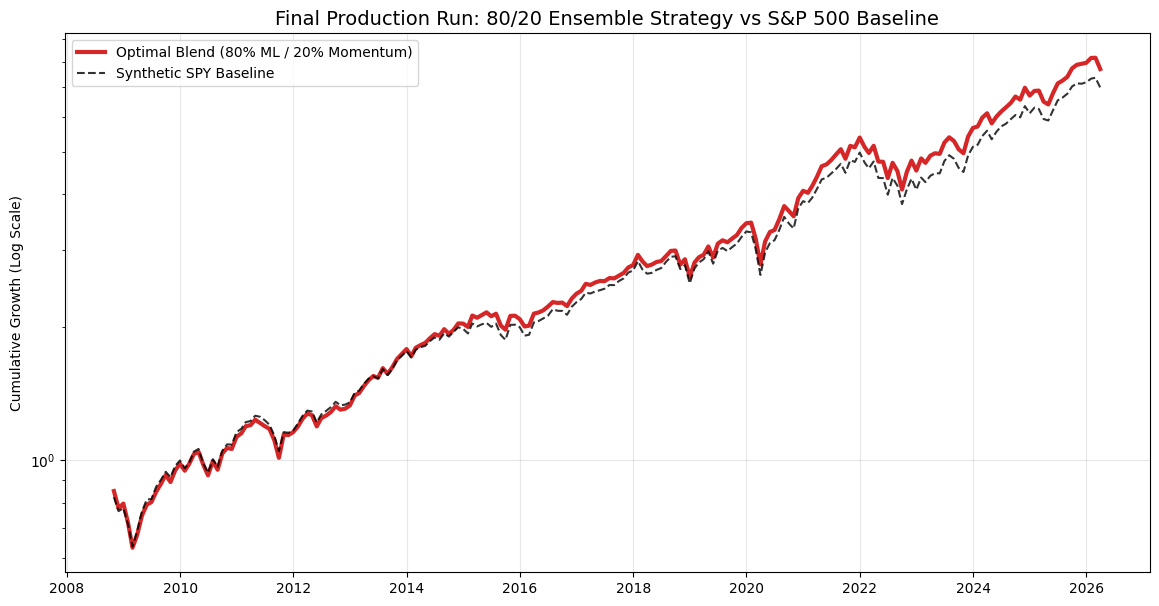


--- FINAL PRODUCTION SCORECARD ---
Strategy:              80% LightGBM / 20% Trailing Momentum
Risk Constraint:       Max 5% Active Weight vs Benchmark
Benchmark Test:        Synthetic S&P 500 (Anchored)
-------------------------------------------------------
Total Return (Strategy):     669.65%
Total Return (Benchmark):    598.69%
Annualized Alpha:              0.58%
Tracking Error:                1.98%
Information Ratio:           0.2905


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Final Production Parameters
momentum_lookback = 6
guardrail = 5.0
ml_weight = 0.80
mom_weight = 0.20
sector_columns = features.columns

portfolio_returns_final = []
synthetic_spy_baseline = []
bt_dates = []

print(f"--- Running Final Production Backtest: {int(ml_weight*100)}% ML / {int(mom_weight*100)}% Momentum ---")

for idx, current_date in enumerate(dates):
    current_idx = features.index.get_loc(current_date)

    # Ensure enough history for the momentum calculation
    if current_idx < momentum_lookback:
        continue

    current_signals = historical_signals[historical_signals['ref.date'].dt.to_period('M') == current_date.to_period('M')].copy()

    if not current_signals.empty:
        # 2. Map Baseline Synthetic Weights
        current_synthetic_weights = historical_inferred_weights[idx]
        weight_map = dict(zip(sector_columns, current_synthetic_weights))

        current_signals['spy_weight'] = current_signals['ticker'].map(weight_map).astype(float)
        current_signals = current_signals.dropna(subset=['spy_weight'])
        current_signals['spy_weight'] = (current_signals['spy_weight'] / current_signals['spy_weight'].sum()) * 100

        # 3. Calculate 6-Month Momentum Score
        past_6m_returns = (1 + features.iloc[current_idx - momentum_lookback : current_idx]).prod() - 1
        mom_scores = past_6m_returns.rank(pct=True)
        current_signals['mom_score'] = current_signals['ticker'].map(dict(mom_scores)).astype(float)

        # 4. Apply the 80/20 Blended Weighting
        current_signals['blended_score'] = (current_signals['conviction_score'] * ml_weight) + (current_signals['mom_score'] * mom_weight)

        # 5. Optimize the allocations
        sig_blend = current_signals.copy()
        sig_blend['conviction_score'] = sig_blend['blended_score']
        alloc_blend = optimize_weights(sig_blend, max_shift=guardrail)

        # 6. Calculate actual returns
        X_current = features.loc[current_date].values
        return_map = dict(zip(sector_columns, X_current))

        ret_blend = sum((row['target_weight'] / 100.0) * return_map[row['ticker']] for _, row in alloc_blend.iterrows())

        portfolio_returns_final.append(ret_blend)
        synthetic_spy_baseline.append(replicated_returns[idx])
        bt_dates.append(current_date)

# 7. Compile Results
final_df = pd.DataFrame({
    'Blended_80_20': portfolio_returns_final,
    'Synthetic_SPY': synthetic_spy_baseline
}, index=bt_dates)

cum_final = (1 + final_df).cumprod()

# 8. Calculate Final Metrics
total_ret_blend = (cum_final['Blended_80_20'].iloc[-1] - 1) * 100
total_ret_spy = (cum_final['Synthetic_SPY'].iloc[-1] - 1) * 100

alpha_array = final_df['Blended_80_20'] - final_df['Synthetic_SPY']
ann_alpha = alpha_array.mean() * 12 * 100
te = alpha_array.std() * np.sqrt(12) * 100
ir = ann_alpha / te if te != 0 else 0

# 9. Visual Proof
plt.figure(figsize=(14, 7))
plt.plot(cum_final['Blended_80_20'], label='Optimal Blend (80% ML / 20% Momentum)', color='#d62728', linewidth=3)
plt.plot(cum_final['Synthetic_SPY'], label='Synthetic SPY Baseline', color='black', linestyle='--', alpha=0.8)

plt.title('Final Production Run: 80/20 Ensemble Strategy vs S&P 500 Baseline', fontsize=14)
plt.ylabel('Cumulative Growth (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 10. Presentation Scorecard
print("\n" + "="*55)
print("--- FINAL PRODUCTION SCORECARD ---")
print("="*55)
print(f"Strategy:              80% LightGBM / 20% Trailing Momentum")
print(f"Risk Constraint:       Max 5% Active Weight vs Benchmark")
print(f"Benchmark Test:        Synthetic S&P 500 (Anchored)")
print("-" * 55)
print(f"Total Return (Strategy):   {total_ret_blend:>8.2f}%")
print(f"Total Return (Benchmark):  {total_ret_spy:>8.2f}%")
print(f"Annualized Alpha:          {ann_alpha:>8.2f}%")
print(f"Tracking Error:            {te:>8.2f}%")
print(f"Information Ratio:         {ir:>8.4f}")
print("="*55)

In [ ]:
import pandas as pd
import numpy as np

# 1. Production Parameters
momentum_lookback = 6
guardrail = 5.0
ml_weight = 0.80
mom_weight = 0.20

# 2. Isolate the Latest Data (To generate predictions for the upcoming month)
latest_date = df_monthly['ref.date'].max()
print(f"--- Generating Live Trading Orders for Month Following: {latest_date.date()} ---")

latest_data = df_monthly[df_monthly['ref.date'] == latest_date].copy()

# FIX 1: Safely align the index dates
# Find the exact timestamp in the yfinance 'features' dataframe that shares the same Year/Month
target_period = latest_date.to_period('M')
feature_date = features.index[features.index.to_period('M') == target_period][0]
current_idx = features.index.get_loc(feature_date)

# FIX 2: Resolve Variable Collision
# Recreate the exact list of columns the LightGBM model was trained on
cols_to_drop = ['ref.date', 'price.close', 'ret.closing.prices', 'target_next_month_ret', 'target_binary', 'target_class', 'target_rank']
ml_feature_cols = [c for c in df_monthly.columns if c not in cols_to_drop]

# 3. Calculate Live ML Conviction Scores
latest_data['ml_score'] = lgbm_model.predict_proba(latest_data[ml_feature_cols])[:, 1]

# 4. Calculate Live 6-Month Momentum Scores
past_6m_returns = (1 + features.iloc[current_idx - momentum_lookback : current_idx]).prod() - 1
mom_scores = past_6m_returns.rank(pct=True)
latest_data['mom_score'] = latest_data['ticker'].map(dict(mom_scores)).astype(float)

# 5. Blend the Scores (The 80/20 Factor Ensemble)
latest_data['conviction_score'] = (latest_data['ml_score'] * ml_weight) + (latest_data['mom_score'] * mom_weight)

# 6. Set the Baseline S&P 500 Weights
latest_data['spy_weight'] = latest_data['ticker'].map(spy_weights).astype(float)
latest_data = latest_data.dropna(subset=['spy_weight'])
latest_data['spy_weight'] = (latest_data['spy_weight'] / latest_data['spy_weight'].sum()) * 100

# 7. Run the Strict Guardrail Optimizer
live_allocation = optimize_weights(latest_data.copy(), max_shift=guardrail)

# 8. Format the Output Report
live_allocation['active_bet'] = live_allocation['target_weight'] - live_allocation['spy_weight']

# Sort for readability (Overweights at the top, Underweights at the bottom)
report_cols = ['ticker', 'ml_score', 'mom_score', 'conviction_score', 'spy_weight', 'target_weight', 'active_bet']
report = live_allocation[report_cols].copy()
report = report.sort_values('active_bet', ascending=False).reset_index(drop=True)

# 9. Display the Production Trade Sheet
print("\n" + "="*80)
print("                       LIVE PORTFOLIO ALLOCATION PLAN                       ")
print("="*80)
display(report.round(4))
print("="*80)
print(f"Total Target Allocation: {report['target_weight'].sum():.2f}%")
print(f"Total Active Risk Deployed: {report['active_bet'][report['active_bet'] > 0].sum():.2f}% (Limit: {guardrail}%)")

--- Generating Live Trading Orders for Month Following: 2026-03-31 ---

                       LIVE PORTFOLIO ALLOCATION PLAN                       


,ticker,ml_score,mom_score,conviction_score,spy_weight,target_weight,active_bet
0,XLU,0.8011,0.6364,0.7681,2.5297,7.5297,5.0000
1,XLRE,0.7874,0.2727,0.6844,1.9698,6.9698,5.0000
2,XLV,0.6101,0.9091,0.6699,9.3391,14.3391,5.0000
3,XLC,0.7151,0.4545,0.6630,10.4690,15.4690,5.0000
4,XLP,0.7806,0.5455,0.7336,5.1295,10.1295,5.0000
5,XLB,0.3751,0.7273,0.4455,2.0798,0.0000,-2.0798
6,XLE,0.3751,1.0000,0.5001,3.8796,0.0000,-3.8796
7,XLK,0.6085,0.3636,0.5595,33.3567,29.3161,-4.0406
8,XLF,0.6448,0.0909,0.5340,12.5487,7.5487,-5.0000
9,XLY,0.4733,0.1818,0.4150,9.6590,4.6590,-5.0000


Total Target Allocation: 100.00%
Total Active Risk Deployed: 25.00% (Limit: 5.0%)


--- Running Guardrail Sensitivity for 80/20 Ensemble vs. Synthetic SPY ---
Guardrail   2.0%: Total Return =  631.26% | Alpha =   0.24% | TE =  1.02% | IR = 0.2391
Guardrail   3.0%: Total Return =  642.59% | Alpha =   0.34% | TE =  1.33% | IR = 0.2559
Guardrail   4.0%: Total Return =  656.95% | Alpha =   0.47% | TE =  1.65% | IR = 0.2817
Guardrail   5.0%: Total Return =  669.65% | Alpha =   0.58% | TE =  1.98% | IR = 0.2912
Guardrail  10.0%: Total Return =  661.51% | Alpha =   0.59% | TE =  3.55% | IR = 0.1660
Guardrail  15.0%: Total Return =  613.45% | Alpha =   0.24% | TE =  4.47% | IR = 0.0548
Guardrail  20.0%: Total Return =  562.35% | Alpha =  -0.19% | TE =  5.06% | IR = -0.0381
Guardrail  25.0%: Total Return =  535.84% | Alpha =  -0.40% | TE =  5.90% | IR = -0.0677
Guardrail  50.0%: Total Return =  469.25% | Alpha =  -1.00% | TE =  7.16% | IR = -0.1402
Guardrail  75.0%: Total Return =  471.23% | Alpha =  -0.93% | TE =  8.27% | IR = -0.1123
Guardrail 100.0%: Total Return =  500.31%

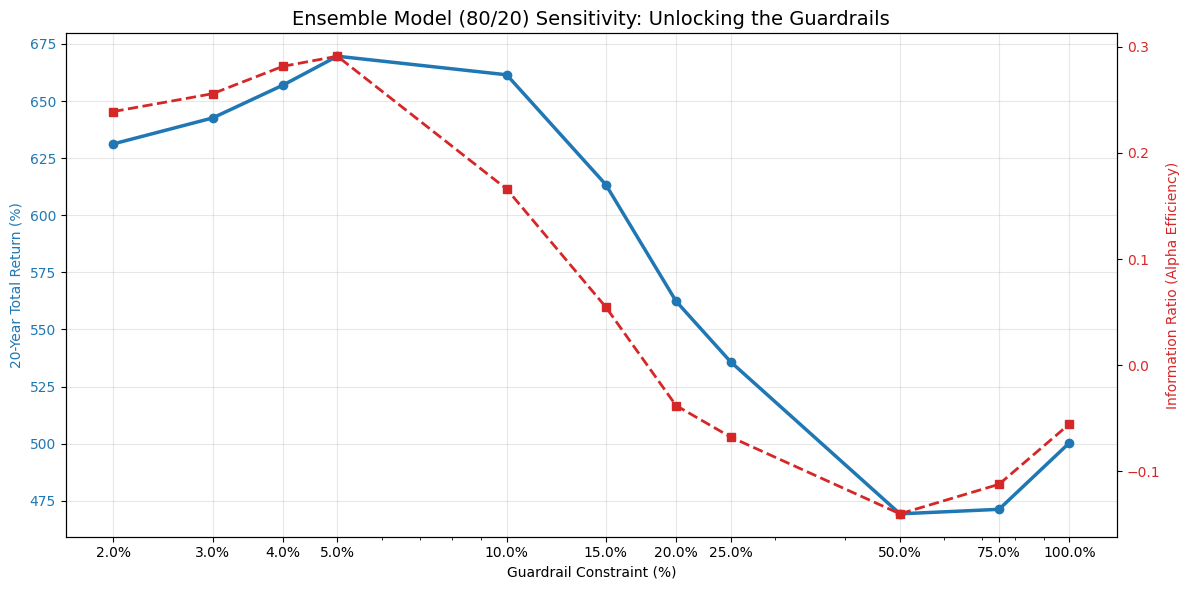


--- NEW OPTIMAL STRATEGY PARAMETERS ---
Optimal Guardrail for Maximum 80/20 Efficiency: 5.0%
Peak Information Ratio: 0.2912


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters for the Sensitivity Test
guardrails = [2.0, 3.0, 4.0, 5.0, 10.0, 15.0, 20.0, 25.0, 50.0, 75.0, 100.0]
optimization_results = []
sector_columns = features.columns

# Lock in the Optimal Blend
ml_weight = 0.80
mom_weight = 0.20
momentum_lookback = 6

print(f"--- Running Guardrail Sensitivity for {int(ml_weight*100)}/{int(mom_weight*100)} Ensemble vs. Synthetic SPY ---")

for g_val in guardrails:
    temp_portfolio = []
    temp_synthetic = []

    for idx, current_date in enumerate(dates):
        current_idx = features.index.get_loc(current_date)

        # Ensure enough history for the momentum calculation
        if current_idx < momentum_lookback:
            continue

        current_signals = historical_signals[historical_signals['ref.date'].dt.to_period('M') == current_date.to_period('M')].copy()

        if not current_signals.empty:
            # Map Baseline Synthetic Weights
            current_synthetic_weights = historical_inferred_weights[idx]
            weight_map = dict(zip(sector_columns, current_synthetic_weights))

            current_signals['spy_weight'] = current_signals['ticker'].map(weight_map).astype(float)
            current_signals = current_signals.dropna(subset=['spy_weight'])
            current_signals['spy_weight'] = (current_signals['spy_weight'] / current_signals['spy_weight'].sum()) * 100

            # Calculate 6-Month Momentum Score
            past_6m_returns = (1 + features.iloc[current_idx - momentum_lookback : current_idx]).prod() - 1
            mom_scores = past_6m_returns.rank(pct=True)
            current_signals['mom_score'] = current_signals['ticker'].map(dict(mom_scores)).astype(float)

            # Apply the 80/20 Weighting
            current_signals['blended_score'] = (current_signals['conviction_score'] * ml_weight) + (current_signals['mom_score'] * mom_weight)

            # Optimize the allocations with the current guardrail
            sig_blend = current_signals.copy()
            sig_blend['conviction_score'] = sig_blend['blended_score']
            alloc_blend = optimize_weights(sig_blend, max_shift=float(g_val))

            # Calculate actual returns
            X_current = features.loc[current_date].values
            return_map = dict(zip(sector_columns, X_current))

            ret_blend = sum((row['target_weight'] / 100.0) * return_map[row['ticker']] for _, row in alloc_blend.iterrows())

            temp_portfolio.append(ret_blend)
            temp_synthetic.append(replicated_returns[idx])

    # Calculate performance metrics for this specific guardrail
    total_ret = (np.prod(1 + np.array(temp_portfolio)) - 1) * 100
    alpha_array = np.array(temp_portfolio) - np.array(temp_synthetic)
    ann_alpha = np.mean(alpha_array) * 12 * 100
    te = np.std(alpha_array) * np.sqrt(12) * 100
    ir = ann_alpha / te if te != 0 else 0

    optimization_results.append({
        'Guardrail': g_val,
        'Total_Return': total_ret,
        'Ann_Alpha': ann_alpha,
        'TE': te,
        'Info_Ratio': ir
    })

    print(f"Guardrail {g_val:>5.1f}%: Total Return = {total_ret:>7.2f}% | Alpha = {ann_alpha:>6.2f}% | TE = {te:>5.2f}% | IR = {ir:>6.4f}")

# 2. Compile and Plot Results
opt_df = pd.DataFrame(optimization_results)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Total Return on Left Axis
color = 'tab:blue'
ax1.set_xlabel('Guardrail Constraint (%)')
ax1.set_ylabel('20-Year Total Return (%)', color=color)
ax1.set_xscale('log')
ax1.set_xticks(guardrails)
ax1.set_xticklabels([f"{g}%" for g in guardrails])
ax1.plot(opt_df['Guardrail'], opt_df['Total_Return'], marker='o', color=color, linewidth=2.5, label='Total Return')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Information Ratio on Right Axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Information Ratio (Alpha Efficiency)', color=color)
ax2.plot(opt_df['Guardrail'], opt_df['Info_Ratio'], marker='s', color=color, linestyle='--', linewidth=2, label='Info Ratio')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ensemble Model (80/20) Sensitivity: Unlocking the Guardrails', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# 3. Final Recommendation
best_g = opt_df.sort_values('Info_Ratio', ascending=False).iloc[0]
print(f"\n--- NEW OPTIMAL STRATEGY PARAMETERS ---")
print(f"Optimal Guardrail for Maximum 80/20 Efficiency: {best_g['Guardrail']}%")
print(f"Peak Information Ratio: {best_g['Info_Ratio']:.4f}")